# 커피브라운 & 올리브그린 — 유사색 + 동일 톤을 수치로 확인하기

영상은 두 색의 관계를 두 축으로 나눠 본다.

1. **색상환 위치**: 두 색의 색상각(hue) 차이. 작으면 유사색(analogous), $180^\circ$ 근처면 보색(complementary).
2. **톤**: 채도(saturation)와 명도(lightness). 두 색이 비슷하면 "동일 톤(대칭)", 크게 벌어지면 "비대칭(위계)".

커피브라운 `#71502F`, 올리브그린 `#788860`을 HSL로 바꿔 이 두 축을 직접 계산해 본다.
비교 대상으로 보색·톤 대칭인 오렌지 & 틸블루, 보색·톤 비대칭인 라임옐로우 & 진보라색을 같은 표에 놓는다.

색상각 차이는 원 위의 거리이므로
$$\Delta h = \min\big(|h_1 - h_2|,\ 360^\circ - |h_1 - h_2|\big)$$
로 계산한다 (최댓값 $180^\circ$).

In [1]:
import colorsys
import os

import plotly.graph_objects as go


def _show(fig):
    try:
        from IPython import get_ipython

        if get_ipython() is not None:
            fig.show()
    except ImportError:
        pass


HERE = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()


def hex_to_hsl(hex_code: str) -> tuple[float, float, float]:
    """'#RRGGBB' -> (hue[deg], saturation[%], lightness[%])."""
    r, g, b = (int(hex_code[i : i + 2], 16) / 255 for i in (1, 3, 5))
    h, l, s = colorsys.rgb_to_hls(r, g, b)  # 표준 라이브러리는 HLS 순서로 반환
    return h * 360, s * 100, l * 100


for name, hx in [("커피브라운", "#71502F"), ("올리브그린", "#788860")]:
    h, s, l = hex_to_hsl(hx)
    print(f"{name} {hx}: hue={h:6.1f}°, sat={s:5.1f}%, light={l:5.1f}%")

커피브라운 #71502F: hue=  30.0°, sat= 41.2%, light= 31.4%
올리브그린 #788860: hue=  84.0°, sat= 17.2%, light= 45.5%


두 색의 색상각은 $30^\circ$와 $84^\circ$로 색상환에서 **같은 노랑-초록 쪽 사분면**에 붙어 있다.
채도는 둘 다 50% 아래(탁한 색, "회색기가 약간 섞여 있다"), 명도는 둘 다 30~45%대(중간 어두움)라 톤이 비슷하다.

이제 다른 두 쌍과 같은 잣대로 비교한다.

In [2]:
PAIRS = {
    "커피브라운 & 올리브그린": (("커피브라운", "#71502F"), ("올리브그린", "#788860")),
    "오렌지 & 틸블루": (("오렌지", "#D96629"), ("틸블루", "#0093A5")),
    "라임옐로우 & 진보라색": (("라임옐로우", "#C7D14F"), ("진보라색", "#501345")),
}


def hue_distance(h1: float, h2: float) -> float:
    d = abs(h1 - h2) % 360
    return min(d, 360 - d)


def classify(dh: float, s1: float, s2: float, dl: float) -> tuple[str, str]:
    """색상환 관계: 60° 이내 유사색, 150° 이상 보색, 그 사이는 준보색.
    톤 관계: 명도 차이 25%p 이내이고 채도가 같은 쪽(둘 다 50% 이상 또는 둘 다 미만)이면 대칭."""
    wheel = "유사색" if dh <= 60 else ("보색" if dh >= 150 else "준보색")
    same_sat_side = (s1 >= 50) == (s2 >= 50)
    tone = "대칭(동일 톤)" if dl <= 25 and same_sat_side else "비대칭"
    return wheel, tone


print(f"{'조합':<14}{'Δhue':>7}{'sat1':>6}{'sat2':>6}{'Δlight':>8}  색상환 관계  톤 관계")
print("-" * 60)
for pair, ((n1, c1), (n2, c2)) in PAIRS.items():
    h1, s1, l1 = hex_to_hsl(c1)
    h2, s2, l2 = hex_to_hsl(c2)
    dh, dl = hue_distance(h1, h2), abs(l1 - l2)
    wheel, tone = classify(dh, s1, s2, dl)
    print(f"{pair:<14}{dh:>6.1f}°{s1:>5.0f}%{s2:>5.0f}%{dl:>7.1f}%  {wheel:<8}  {tone}")

조합               Δhue  sat1  sat2  Δlight  색상환 관계  톤 관계
------------------------------------------------------------
커피브라운 & 올리브그린   54.0°   41%   17%   14.1%  유사색       대칭(동일 톤)
오렌지 & 틸블루      165.8°   70%  100%   18.2%  보색        대칭(동일 톤)
라임옐로우 & 진보라색   113.8°   59%   62%   37.1%  준보색       비대칭


- **커피브라운 & 올리브그린**: $\Delta h = 54^\circ$로 세 쌍 중 유일하게 색상환에서 인접(유사색). 둘 다 저채도(41%, 17%)이고 명도 차이 $14\%\text{p}$라 동일 톤.
- **오렌지 & 틸블루**: $\Delta h \approx 166^\circ$로 거의 정반대(보색). 둘 다 고채도(70%, 100%)에 명도도 비슷 → 톤은 대칭이지만 "절제하지 않은" 고채도 대칭. 각도가 정반대라 팽팽하게 부딪힌다.
- **라임옐로우 & 진보라색**: HSL(RGB 기반) 색상환에서는 $\Delta h \approx 114^\circ$로 준보색. 영상은 화가의 전통 색상환(RYB)에서 노랑↔보라가 정반대이므로 "보색"이라 부른다.
  어느 색상환을 쓰든 핵심은 명도 차이 $37\%\text{p}$ — 영상이 말한 "명도 극단 격차, 위계"다.

정리하면, 커피브라운·올리브그린 조합만이 **각도도 가깝고 톤도 비슷**하다. 그래서 두 색의 경계가 튀지 않고 오브제가 자연스럽게 이어진다.

## 색상환(hue wheel) 위에 세 쌍 찍어 보기

각도 = hue, 반지름 = 채도(%)로 극좌표 산점도를 그린다. 점 색은 실제 HEX.
같은 쌍은 선으로 이었다. 유사색 쌍은 선이 짧고 반지름도 비슷하며, 보색 쌍은 원의 중심을 가로지른다.

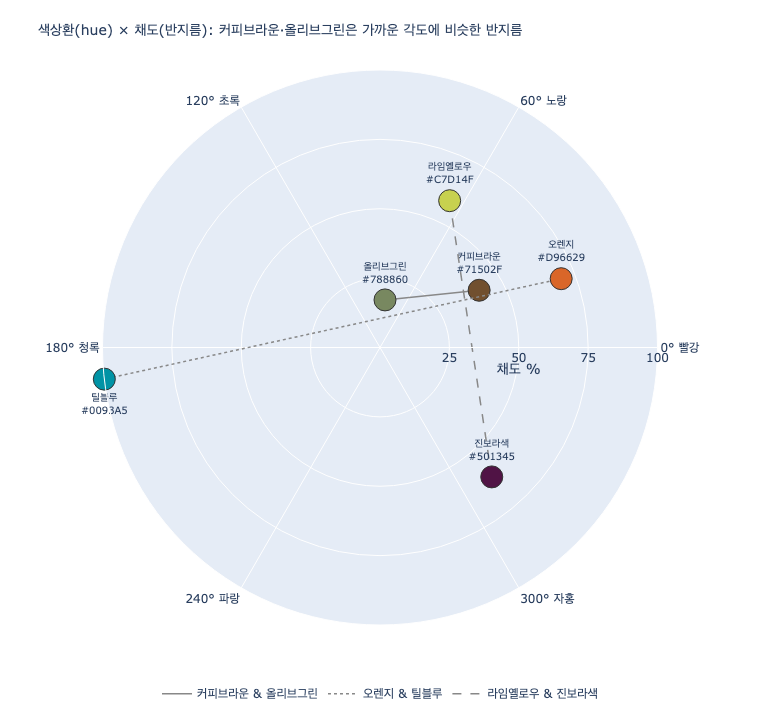

saved: /Users/swcho/projects/swcho/flash-man/default/books/260923 그대로 갖다 쓰는 색깔 조합 16가지/.fm/hints/14a774e2-4c10-4fe0-830c-274c69ad55bf/expy.png


In [3]:
fig = go.Figure()
dash_styles = {
    "커피브라운 & 올리브그린": "solid",
    "오렌지 & 틸블루": "dot",
    "라임옐로우 & 진보라색": "dash",
}
for pair, colors in PAIRS.items():
    hsl = [hex_to_hsl(c) for _, c in colors]
    thetas = [h for h, _, _ in hsl]
    rs = [s for _, s, _ in hsl]
    fig.add_trace(
        go.Scatterpolar(
            r=rs,
            theta=thetas,
            mode="lines",
            line=dict(color="#888888", width=1.5, dash=dash_styles[pair]),
            name=pair,
            legendgroup=pair,
            hoverinfo="skip",
        )
    )
    fig.add_trace(
        go.Scatterpolar(
            r=rs,
            theta=thetas,
            mode="markers+text",
            marker=dict(size=22, color=[c for _, c in colors], line=dict(color="#333333", width=1)),
            text=[f"{n}<br>{c}" for n, c in colors],
            textposition=["top center", "bottom center"] if pair == "오렌지 & 틸블루" else "top center",
            textfont=dict(size=10),
            legendgroup=pair,
            showlegend=False,
            hovertemplate="%{text}<br>hue=%{theta:.1f}°, sat=%{r:.1f}%<extra></extra>",
        )
    )

fig.update_layout(
    title=dict(
        text="색상환(hue) × 채도(반지름): 커피브라운·올리브그린은 가까운 각도에 비슷한 반지름",
        font=dict(size=14),
    ),
    polar=dict(
        angularaxis=dict(direction="counterclockwise", rotation=0, tickmode="array",
                         tickvals=[0, 60, 120, 180, 240, 300],
                         ticktext=["0° 빨강", "60° 노랑", "120° 초록", "180° 청록", "240° 파랑", "300° 자홍"]),
        radialaxis=dict(range=[0, 100], title="채도 %", tickvals=[25, 50, 75, 100]),
    ),
    legend=dict(orientation="h", yanchor="bottom", y=-0.15, x=0.5, xanchor="center"),
    width=760,
    height=720,
    margin=dict(t=70, b=90, l=40, r=40),
)
_show(fig)
fig.write_image(os.path.join(HERE, "expy.png"), scale=2)
print("saved:", os.path.join(HERE, "expy.png"))

## 정리

| 조합 | 색상환 | 톤 | 효과 |
|---|---|---|---|
| 커피브라운 & 올리브그린 | 유사색 ($\Delta h = 54^\circ$) | 동일 톤 (저채도·중저명도) | 경계가 흐려져 오브제가 자연스럽게 이어짐 |
| 오렌지 & 틸블루 | 보색 ($\Delta h \approx 166^\circ$) | 둘 다 고채도 (대칭, 절제 없음) | 팽팽한 대립, 인물·배경 분리 |
| 라임옐로우 & 진보라색 | 보색(RYB) / 준보색(HSL $\Delta h \approx 114^\circ$) | 명도 극단 격차 (비대칭) | 주도색·보조색 위계 |

질문의 답: 커피브라운과 올리브그린은 **색상환에서 인접한 유사색**이고 **동일한 톤**을 유지한다. 그래서 색의 경계와 오브제를 자연스럽게 연결한다.